![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [48]:
# Importación librerías
import numpy as np
import keras 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from keras import initializers
from keras import optimizers
from keras.models import Sequential, load_model
from keras.layers import Dense
from keras.layers import Dropout

from livelossplot import PlotLossesKeras
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scikeras.wrappers import KerasRegressor
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [34]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


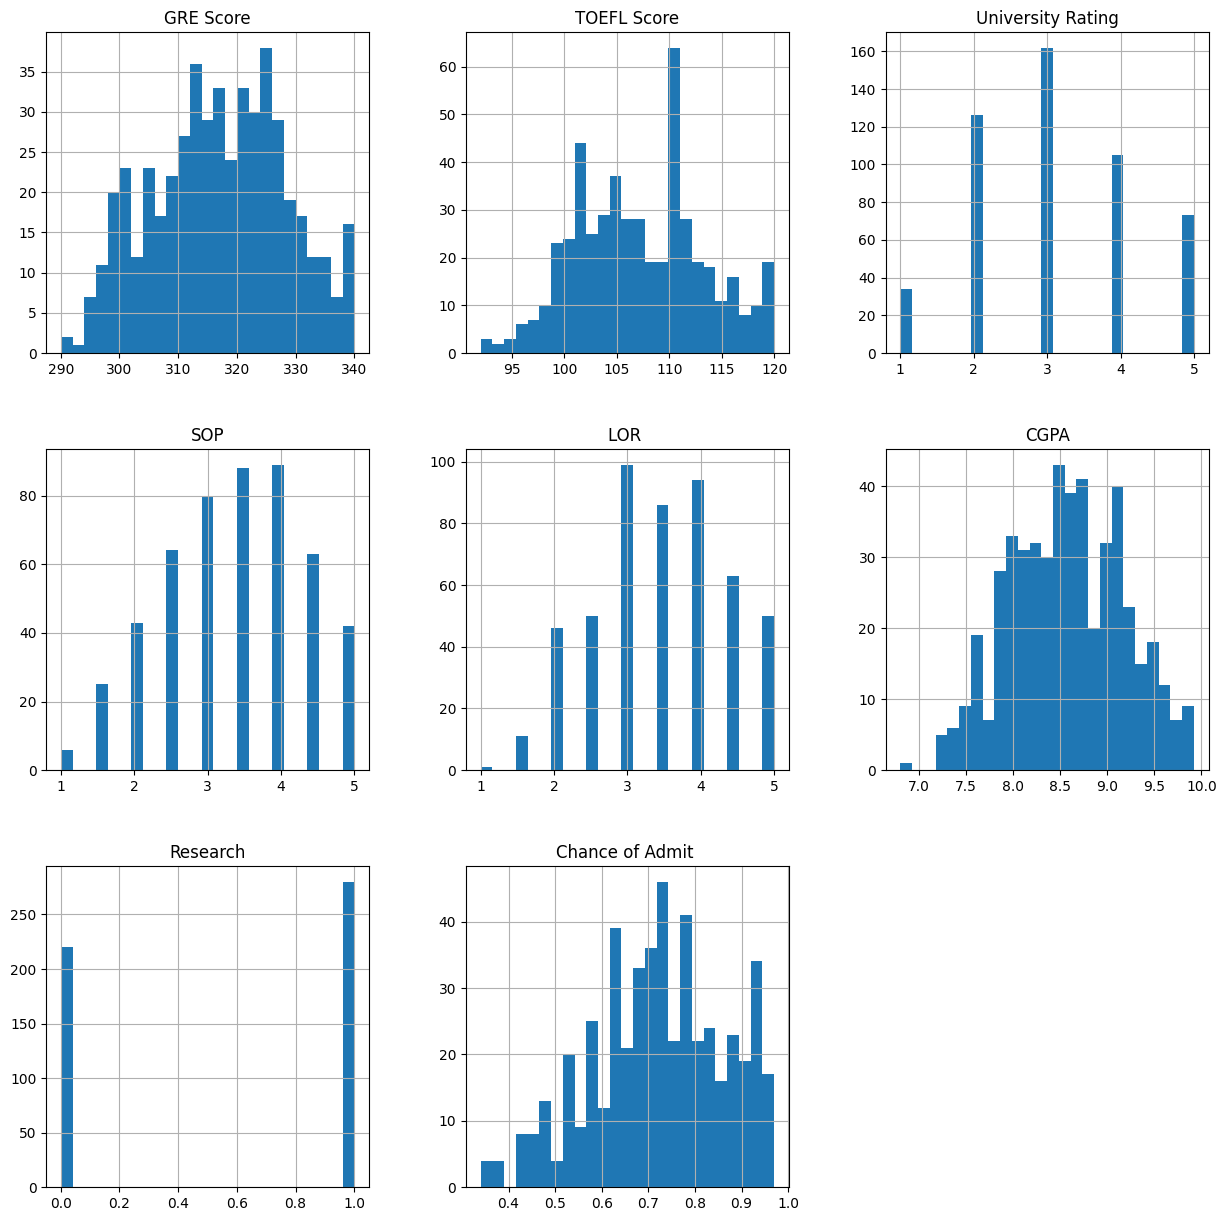

In [35]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [36]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [37]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

In [38]:
#Escalamiento de los datos
scaler = StandardScaler()
scaler.fit(X)

# Transformación de los set de entrenamiento y test
X_train = pd.DataFrame(data=scaler.transform(xTrain), columns=xTrain.columns, index=xTrain.index)
X_test = pd.DataFrame(data=scaler.transform(xTest), columns=xTest.columns, index=xTest.index)

X_train = np.array(X_train)
Y_train = np.array(yTrain)

X_test = np.array(X_test)
Y_test = np.array(yTest)

# Definición de dimensiones de salida, varaibles de interés
output_var = 1
print(output_var, ' output variables')

# Definición de dimensiones de entrada, varaibles predictoras
dims = X_train.shape[1]
print(dims, 'input variables')

1  output variables
7 input variables


## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

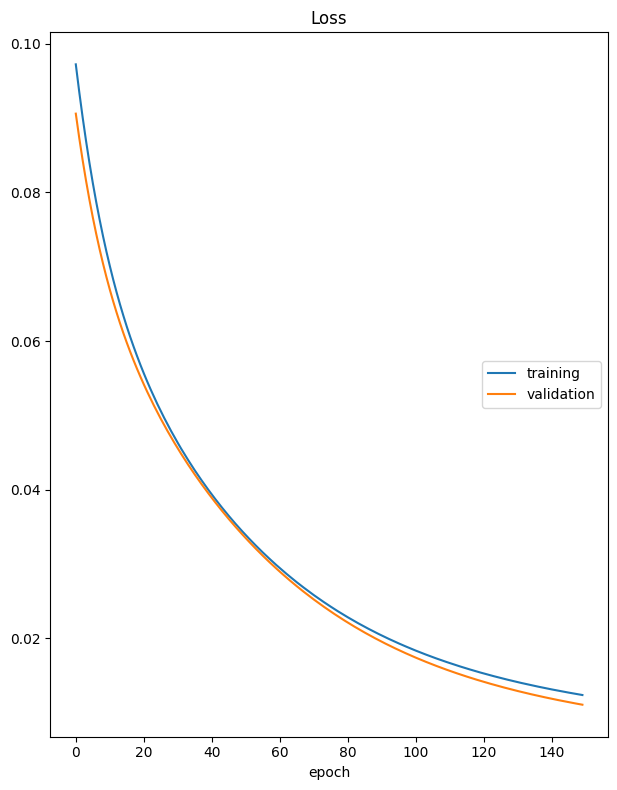

Loss
	training         	 (min:    0.012, max:    0.097, cur:    0.012)
	validation       	 (min:    0.011, max:    0.091, cur:    0.011)
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0123 - val_loss: 0.0110
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Mejor desempeño: -0.0804504315333313
Mejores parámetros: {'epochs': 150, 'loss': 'mean_squared_error', 'optimizer': 'sgd'}
Error Absoluto Medio (MAE): 0.0859
Error Cuadrático Medio (MSE): 0.0110


In [43]:
# Celda 1
def crear_modelo_una_capa(optimizer='adam', loss='mean_squared_error'):
    model = Sequential()
    model.add(Dense(output_var, input_shape=(dims,), activation='sigmoid'))
    model.compile(optimizer=optimizer, loss=loss)
    return model

model_wrapper = KerasRegressor(model=crear_modelo_una_capa, verbose=0)

param_grid = {
    'optimizer': ['adam', 'sgd', 'rmsprop'],
    'loss': ['mean_squared_error', 'binary_crossentropy'],
    'epochs': [50, 100, 150],
}

grid = GridSearchCV(estimator=model_wrapper, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_error')
grid_result = grid.fit(X_train, Y_train)

best_config = grid_result.best_params_
model_final = crear_modelo_una_capa(optimizer=best_config['optimizer'], loss=best_config['loss'])
model_final.fit(X_train, Y_train, epochs=best_config['epochs'], validation_data=(X_test, Y_test), verbose=1, callbacks=[PlotLossesKeras()])

y_pred = model_final.predict(X_test)
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)

print(f"\nMejor desempeño: {grid_result.best_score_}")
print(f"Mejores parámetros: {grid_result.best_params_}")

print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")

## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

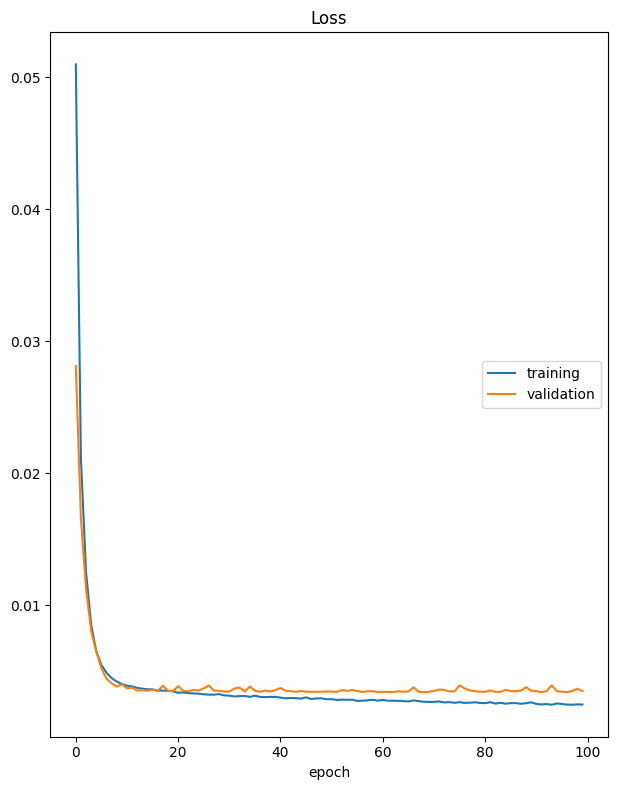

Loss
	training         	 (min:    0.002, max:    0.051, cur:    0.002)
	validation       	 (min:    0.003, max:    0.028, cur:    0.003)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0025 - val_loss: 0.0035
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Mejor desempeño: -0.04567364278383299
Mejores parámetros: {'epochs': 100, 'loss': 'mean_squared_error', 'model__num_neuronas': 128, 'optimizer': 'rmsprop'}
Error Absoluto Medio (MAE): 0.0419
Error Cuadrático Medio (MSE): 0.0035


In [46]:
# Celda 2
def crear_modelo_dos_capas(optimizer='adam', loss='mean_squared_error', num_neuronas=256):
    model = Sequential()
    model.add(Dense(num_neuronas, input_shape=(dims,), activation='relu'))
    model.add(Dense(output_var, activation='sigmoid'))
    model.compile(optimizer=optimizer, loss=loss)
    return model

model_wrapper_2_capas = KerasRegressor(model=crear_modelo_dos_capas, verbose=0)

param_grid_2_capas = {
    'optimizer': ['adam', 'sgd', 'rmsprop'],
    'loss': ['mean_squared_error', 'binary_crossentropy'],
    'epochs': [100, 150],
    'model__num_neuronas': [128, 256]
}

grid_2_capas = GridSearchCV(estimator=model_wrapper_2_capas, param_grid=param_grid_2_capas, cv=3, scoring='neg_mean_absolute_error')
grid_result_2_capas = grid_2_capas.fit(X_train, Y_train)

best_config_2_capas = grid_result_2_capas.best_params_
model_final_2_capas = crear_modelo_dos_capas(optimizer=best_config_2_capas['optimizer'], loss=best_config_2_capas['loss'], num_neuronas=best_config_2_capas['model__num_neuronas'])
model_final_2_capas.fit(X_train, Y_train, epochs=best_config_2_capas['epochs'], validation_data=(X_test, Y_test), verbose=1, callbacks=[PlotLossesKeras()])

y_pred_2_capas = model_final_2_capas.predict(X_test)
mae_2_capas = mean_absolute_error(Y_test, y_pred_2_capas)
mse_2_capas = mean_squared_error(Y_test, y_pred_2_capas)

print(f"\nMejor desempeño: {grid_result_2_capas.best_score_}")
print(f"Mejores parámetros: {grid_result_2_capas.best_params_}")

print(f"Error Absoluto Medio (MAE): {mae_2_capas:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_2_capas:.4f}")

## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

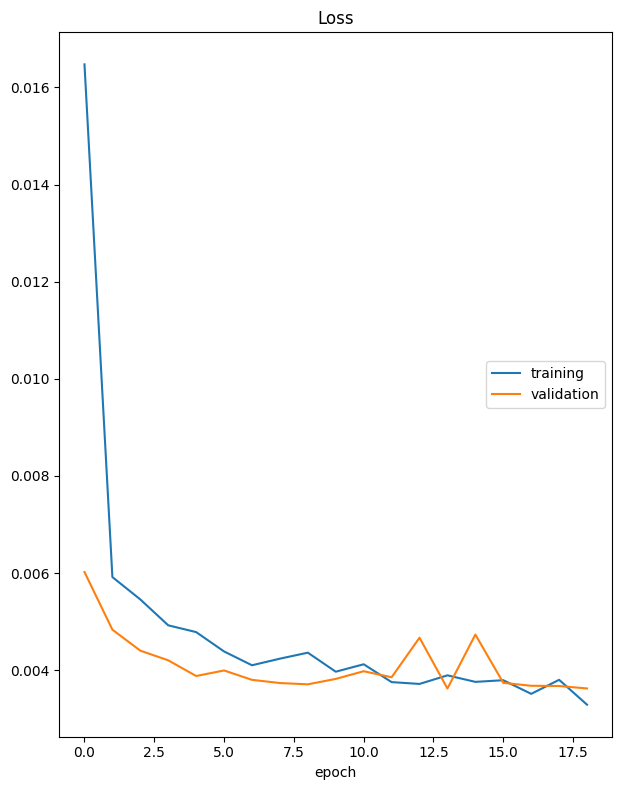

Loss
	training         	 (min:    0.003, max:    0.016, cur:    0.003)
	validation       	 (min:    0.004, max:    0.006, cur:    0.004)
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0033 - val_loss: 0.0036


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Mejor desempeño: -0.06464003976201341
Mejores parámetros: {'loss': 'mean_squared_error', 'model__num_neuronas': 256, 'optimizer': 'rmsprop'}
Error Absoluto Medio (MAE): 0.0444
Error Cuadrático Medio (MSE): 0.0036


In [49]:
# Celda 3
def crear_modelo_multi_capa(optimizer='adam', loss='mean_squared_error', num_neuronas=256):
    model = Sequential()
    model.add(Dense(num_neuronas, input_shape=(dims,), activation='relu'))
    model.add(Dropout(0.2))

    model.add(Dense(num_neuronas,activation='relu'))
    model.add(Dropout(0.1))

    model.add(Dense(output_var, activation='sigmoid'))

    model.compile(optimizer=optimizer, loss=loss)
    return model

model_wrapper_multi = KerasRegressor(model=crear_modelo_multi_capa, verbose=0)

param_grid_multi = {
    'optimizer': ['adam', 'sgd', 'rmsprop'],
    'loss': ['mean_squared_error', 'binary_crossentropy'],
    'model__num_neuronas': [128, 256]
}

early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=0) 
fBestModel = 'best_model.h5'
best_model = ModelCheckpoint(fBestModel, verbose=0, save_best_only=True)

grid_multi = GridSearchCV(estimator=model_wrapper_multi, param_grid=param_grid_multi, cv=3, scoring='neg_mean_absolute_error')
grid_result_multi = grid_multi.fit(X_train, Y_train, validation_data=(X_test, Y_test), callbacks=[early_stop])
best_config_multi = grid_result_multi.best_params_

model_final_multi = crear_modelo_multi_capa(optimizer=best_config_multi['optimizer'], loss=best_config_multi['loss'], num_neuronas=best_config_multi['model__num_neuronas'])
model_final_multi.fit(X_train, Y_train, epochs=300, validation_data=(X_test, Y_test), verbose=1, callbacks=[best_model, early_stop, PlotLossesKeras()])
mejor_modelo = load_model('best_model.h5')

y_pred_multi = mejor_modelo.predict(X_test)
mae_multi = mean_absolute_error(Y_test, y_pred_multi)
mse_multi = mean_squared_error(Y_test, y_pred_multi)

print(f"\nMejor desempeño: {grid_result_multi.best_score_}")
print(f"Mejores parámetros: {grid_result_multi.best_params_}")

print(f"Error Absoluto Medio (MAE): {mae_multi:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_multi:.4f}")

## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [ ]:
# Celda 4
modelos = ['Punto 1\n(1 capa)', 'Punto 2\n(2 capas)', 'Punto 3\n(multicapa + dropout + ES)']
mae_vals = [mae, mae_2_capas, mae_multi]
mse_vals = [mse, mse_2_capas, mse_multi]
mejor_idx = int(np.argmin(mae_vals))

x = np.arange(len(modelos))
ancho = 0.38

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(11, 6.5), dpi=110)

color_mae = '#2E86AB'
color_mse = '#E63946'

barras_mae = ax.bar(x - ancho/2, mae_vals, ancho, label='MAE',
                    color=color_mae, edgecolor='white', linewidth=1.5, zorder=3)
barras_mse = ax.bar(x + ancho/2, mse_vals, ancho, label='MSE',
                    color=color_mse, edgecolor='white', linewidth=1.5, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11, fontweight='bold')
ax.set_ylabel('Error', fontsize=12, fontweight='bold')
ax.set_title('Comparación de desempeño entre modelos',
             fontsize=15, fontweight='bold', pad=18)
ax.legend(fontsize=11, loc='upper right', frameon=True,
          fancybox=True, shadow=True)
ax.grid(axis='y', alpha=0.4, linestyle='--', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=10)

# Espacio extra arriba para que las etiquetas no se salgan
ax.set_ylim(0, max(max(mae_vals), max(mse_vals)) * 1.18)

# Etiquetas con el valor encima de cada barra
for barras, color in [(barras_mae, color_mae), (barras_mse, color_mse)]:
    for b in barras:
        h = b.get_height()
        ax.annotate(f'{h:.4f}',
                    xy=(b.get_x() + b.get_width() / 2, h),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color=color)


plt.tight_layout()
plt.show()

# Tabla resumen
print("\n" + "═" * 55)
print(f"{'Resumen de desempeño':^55}")
print("═" * 55)
print(f"{'Modelo':<35} {'MAE':>8} {'MSE':>8}")
print("─" * 55)
for nombre, m, s in zip(modelos, mae_vals, mse_vals):
    nombre_plano = nombre.replace('\n', ' ')
    marca = ' ★' if mae_vals.index(m) == mejor_idx else '  '
    print(f"{nombre_plano:<35} {m:>8.4f} {s:>8.4f}{marca}")
print("═" * 55)